# Code Assignment 18 — NYC COVID-19 Daily Counts (Time-Series)

**Dataset:** [NYC DOHMH — *COVID-19 Daily Counts of Cases, Hospitalizations, and Deaths*](https://data.cityofnewyork.us/Health/COVID-19-Daily-Counts-of-Cases-Hospitalizations-an/rc75-m7u3/about_data) 
**Focus:** Build a clean **daily** time series, **visualize** with resampling (month-end, yearly), **decompose** (trend/seasonality/residual), and **test stationarity** (ADF).  
**No forecasting models** and **no ACF/PACF** yet.

---

## Instructor Guidance

 Build a clean **daily** time series from NYC COVID-19 data using **SQLite** for filtering; visualize resampled views; run **decomposition** and **ADF**.

### Pseudocode Plan 
1) **Download CSV → pandas** (parse dates) → `pd.read_csv(path, parse_dates=['date_of_interest'])`  
2) **Normalize columns to lowercase** → `df.columns = df.columns.str.lower()`  
3) **Write to SQLite** → `import sqlite3; conn = sqlite3.connect('nyc_ts.db'); df.to_sql('covid_daily', conn, if_exists='replace', index=False)`  
4) **Filter to a time window** (choose recent 12–24 months, select only needed columns)   
5) **Set DateTime index & daily frequency** → `df.set_index('date_of_interest').asfreq('D')`  
6) **Pick ONE target series** (`case_count` | `hosp_count` | `death_count`) and for now fill in missing values with zero 
7) **Resample for EDA**  
   - Month-end totals → `df[[target]].resample('M').sum()`  
   - Yearly totals → use the month-end totals to figure this code out 
8) **Decompose** (weekly seasonality) → `seasonal_decompose()`  
9) **ADF test** (raw → difference)  
   - Raw → `adfuller(s.dropna())`  
   - First difference 
10) **Short write-up**: describe trend/seasonality, ADF p-values before/after differencing, and business implications.


## Your Task

### Step 0:  Run the imports below

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


### Step 1:  Read in the data and look at it

In [137]:
df = pd.read_csv("../data/covid copy.csv",parse_dates=['date_of_interest'])
df.columns = df.columns.str.lower()

df.info()
display(df.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2054 entries, 0 to 2053
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date_of_interest                 2054 non-null   datetime64[ns]
 1   case_count                       2054 non-null   object        
 2   probable_case_count              2054 non-null   object        
 3   hospitalized_count               2054 non-null   object        
 4   death_count                      2054 non-null   int64         
 5   case_count_7day_avg              2054 non-null   object        
 6   all_case_count_7day_avg          2054 non-null   object        
 7   hosp_count_7day_avg              2054 non-null   object        
 8   death_count_7day_avg             2054 non-null   int64         
 9   bx_case_count                    2054 non-null   object        
 10  bx_probable_case_count           2054 non-null   object     

,date_of_interest,case_count,probable_case_count,hospitalized_count,death_count,case_count_7day_avg,all_case_count_7day_avg,hosp_count_7day_avg,death_count_7day_avg,bx_case_count,...,si_case_count,si_probable_case_count,si_hospitalized_count,si_death_count,si_probable_case_count_7day_avg,si_case_count_7day_avg,si_all_case_count_7day_avg,si_hospitalized_count_7day_avg,si_death_count_7day_avg,incomplete
2049,2025-10-09,108,70,4,2,121,204,16,1,18,...,3,8,1,0,7,7,14,1,0,"61,030"
2050,2025-10-10,87,54,2,0,113,189,13,1,10,...,10,6,0,0,7,7,14,1,0,"61,030"
2051,2025-10-11,69,45,1,0,109,182,11,0,15,...,3,3,0,0,6,7,13,1,0,"61,030"
2052,2025-10-12,71,37,1,0,105,174,8,0,5,...,7,1,0,0,6,7,13,1,0,"61,030"
2053,2025-10-13,61,51,0,0,92,153,6,0,10,...,1,2,0,0,5,6,11,0,0,"61,030"


In [ ]:
# IF WE WERE READING FROM SQLITE (practice)

#import sqlite3

#conn = sqlite3.connect('nyc_ts.db')
#cursor = conn.cursor()

#data = 
#"""
#SELECT *
#FROM nyc_ts
#"""

#cursor.execute(data)

#df = pd.read_sql_query(data,conn)

#df

### Step 2:  Keep needed columns & filter by time window 

- Chose any time window (use most recent data) that is 6 to 12 months long 


In [138]:
# CELL 2 — Keep needed columns & filter by date in Pandas (no SQL)
# taking 2 years of the most recent data (about 730 rows)
recent = df[(df['date_of_interest'] <= '2025-12-31') & (df['date_of_interest'] >= '2023-01-01')]



### Step 3:  Create a time series object and pick your Y (case count, hospitalized count, death count, etc)

- Use the `date_of_interest` column as your index and keep it at "Daily" frequency (try looking up set_index() in pandas)
- Fill in missing values of Y with zero 

In [139]:
#Build a daily time series, pick a target metric
# Set time index & ensure daily frequency
recent = recent.set_index('date_of_interest').asfreq('D')

In [140]:
# no na values in recent (df with recent values)
# precautionary fillna with 0
recent = recent.fillna(0)



In [141]:
# cleaning data to be numeric
y = pd.to_numeric(recent['hospitalized_count'])

### Step 4 - Visualize the Series

<Axes: xlabel='date_of_interest'>

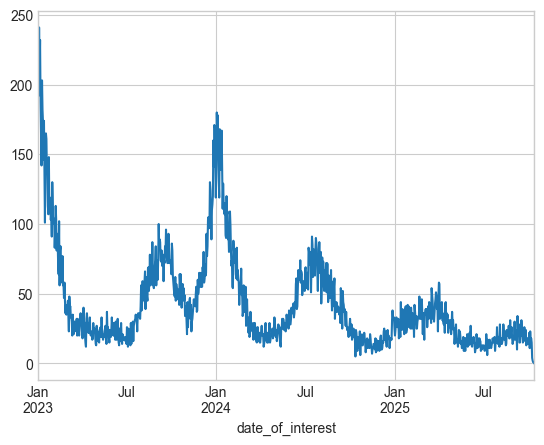

In [142]:
y.plot(kind='line')

### Step 5 - Resampling EDA:  Month-end and Yearly totals 

- Use the `.resample()` function to resample the series to month end and yearly 
- Visualize both resampled series 

In [143]:
# CELL 5 — Resampling EDA: Month-end and Yearly totals (Pandas-only)

# showing aggregates of monthly data
# keep in mind month of October 2025 only includes days up to 10-13-2025
m_end = y.resample('ME').sum() # Month-end totals

# showing aggregates of yearly data
# keep in mind 2025 only includes days up to 10-13-2025
y_sum = y.resample('YE').sum()  # Yearly totals

print('MONTHLY RESAMPLE:')
display(m_end)
print('MONTHLY RESAMPLE:')
display(y_sum)

MONTHLY RESAMPLE:


date_of_interest
2023-01-31    4707
2023-02-28    2057
2023-03-31     948
2023-04-30     711
2023-05-31     681
2023-06-30     642
2023-07-31     852
2023-08-31    1837
2023-09-30    2316
2023-10-31    1650
2023-11-30    1272
2023-12-31    3066
2024-01-31    3826
2024-02-29    1739
2024-03-31     792
2024-04-30     630
2024-05-31     798
2024-06-30    1492
2024-07-31    2209
2024-08-31    1776
2024-09-30    1069
2024-10-31     568
2024-11-30     391
2024-12-31     624
2025-01-31     908
2025-02-28     923
2025-03-31    1172
2025-04-30    1008
2025-05-31     524
2025-06-30     448
2025-07-31     444
2025-08-31     609
2025-09-30     624
2025-10-31     142
Freq: ME, Name: hospitalized_count, dtype: int64

MONTHLY RESAMPLE:


date_of_interest
2023-12-31    20739
2024-12-31    15914
2025-12-31     6802
Freq: YE-DEC, Name: hospitalized_count, dtype: int64

<Axes: xlabel='date_of_interest'>

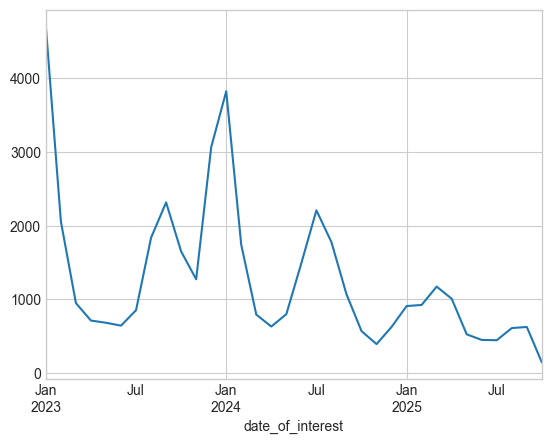

In [144]:
m_end.plot(kind='line')

<Axes: xlabel='date_of_interest'>

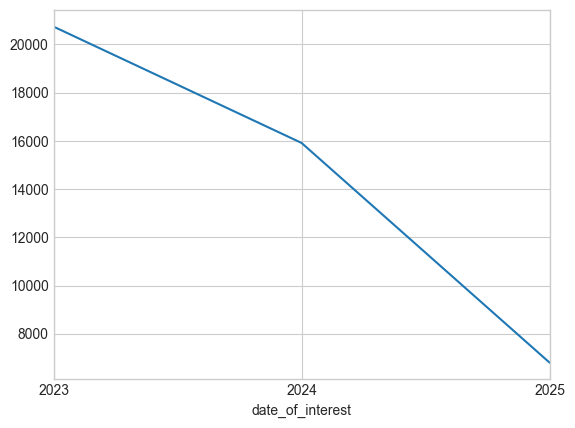

In [145]:
# not so good for EDA as 2025 doesn't have as much data
y_sum.plot(kind = 'line')

### Step 6 - Decompose the original time series object (use period = 7 since that represents weekly seasonality)
- Make a visual of the decomposition

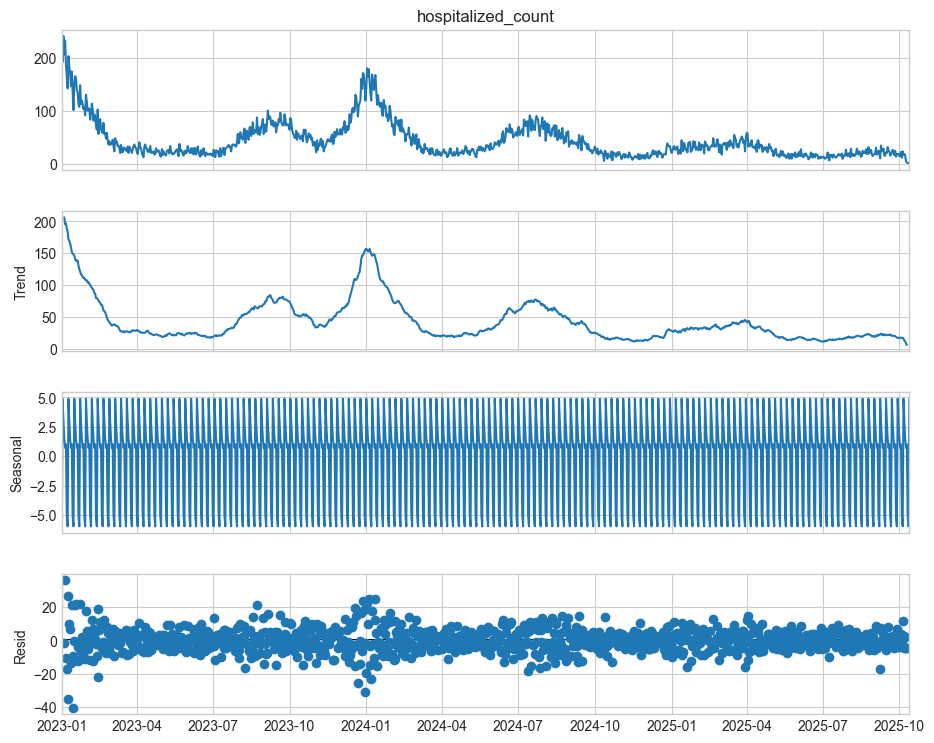

In [150]:
# CELL 6 — Decomposition (weekly seasonality → period=7)

# Decompose the time series (assuming a 12-month cycle)
decomp = seasonal_decompose(y, model='additive', period=7)

# Plot the decomposition
fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.show()

### Step 7 - Do the ADF test for stationarity on the original time series and for taking a difference of 1 on the time series 
- Be sure to drop missing values (if you didn't above) 

In [147]:
# CELL 7 — ADF stationarity test: raw → difference (1) → (optional) seasonal diff(7)

print('--- ADF Test on Original Data ---')
adf_stat, pval, *_ = adfuller(y)
print(f'ADF: {adf_stat:.2f} | p-value: {pval:.3f}')


--- ADF Test on Original Data ---
ADF: -3.65 | p-value: 0.005


In [148]:
# Fix: Make it stationary by "differencing" (subtracting the previous value)
y_diff = y.diff().dropna() # Drop the first NaN value

print('\n--- ADF Test on Differenced Data ---')
adf_stat_d, pval_d, *_ = adfuller(y_diff)
print(f'ADF: {adf_stat_d:.2f} | p-value: {pval_d:.3f}')



--- ADF Test on Differenced Data ---
ADF: -4.76 | p-value: 0.000


## We Share — Reflection 

1) **Narrative:** One sentence describing the series over your window (trend + weekly seasonality + volatility).

The hospitalization count shows a generally stable trend with recurring seasonal spikes in January, though these spikes appear less severe in 2025. Most volatility occurs during these seasonal peaks, while the rest of the series remains relatively consistent.

2) **Stationarity:** Which transform (if any) produced p < 0.05? Why does that matter before modeling?  

For hospitalization count, after implementing an ADF test was proven to be stationary with a p-value below 0.05 at 0.005. After using differencing, our p-value was further reduced and decreased to under 0.000. This proves the alternative hypothesis and ensures our data is stationary. Proving stationarity is important because many time-series models assume constant mean and variance for reliable forecasting.

3) **Operational lens:** Based on month-end and yearly views, what **calendar effects** would you brief stakeholders about?

For most years, the summer shows to have small increases in hospitalization counts which becomes further amplified during the winter months of December, January and February. Stakeholders should plan to increase staffing during December, January and February to anticipate higher hospitalization demand.
